In [1]:

# Internship Week 2 Project


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [3]:
df.shape

(1470, 35)

In [4]:
print("Target Column:")
print(df["Attrition"].value_counts())

Target Column:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [5]:
attrition_rate = (
    df["Attrition"].value_counts(normalize=True)["Yes"]
    * 100
)

print(f"Attrition Rate : {attrition_rate:.2f}%")

Attrition Rate : 16.12%


In [6]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

print("Number of Numerical Columns:", len(num_cols))
print("Number of Categorical Columns:", len(cat_cols))

Number of Numerical Columns: 26
Number of Categorical Columns: 9


In [7]:

print("""
Observation:
The dataset is imbalanced because employees who stayed
significantly outnumber employees who left.
""")


Observation:
The dataset is imbalanced because employees who stayed
significantly outnumber employees who left.



In [8]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [9]:
drop_cols = [
    'EmployeeNumber',
    'EmployeeCount',
    'Over18',
    'StandardHours'
]

df.drop(columns=drop_cols, inplace=True)

print("Columns Dropped Successfully")

Columns Dropped Successfully


In [10]:
df["Attrition"] = df["Attrition"].map({
    "Yes":1,
    "No":0
})

In [11]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

In [12]:
X = pd.get_dummies(
    X,
    drop_first=True
)

print("Encoding Completed")

Encoding Completed


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [14]:
department_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize="index"
) * 100

department_attrition


Attrition,0,1
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


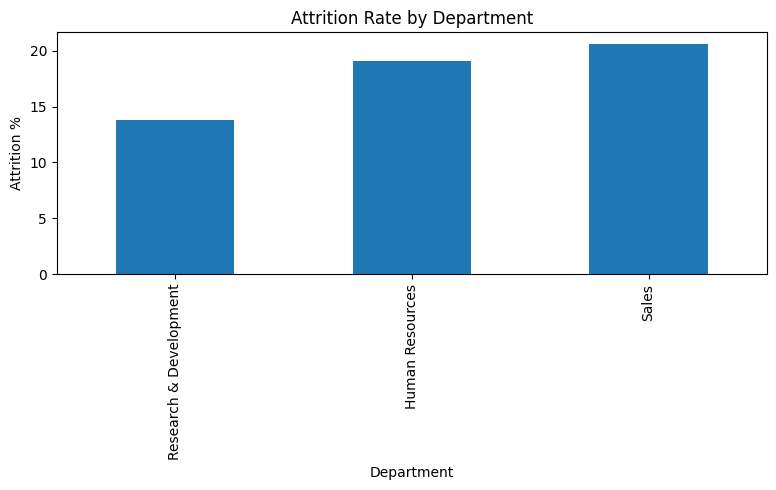

In [15]:
plt.figure(figsize=(8,5))

department_attrition[1].sort_values().plot(
    kind='bar'
)

plt.title("Attrition Rate by Department")
plt.ylabel("Attrition %")
plt.tight_layout()

plt.savefig("chart1_department.png")

plt.show()

In [16]:
jobrole_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize="index"
) * 100

jobrole_attrition

Attrition,0,1
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


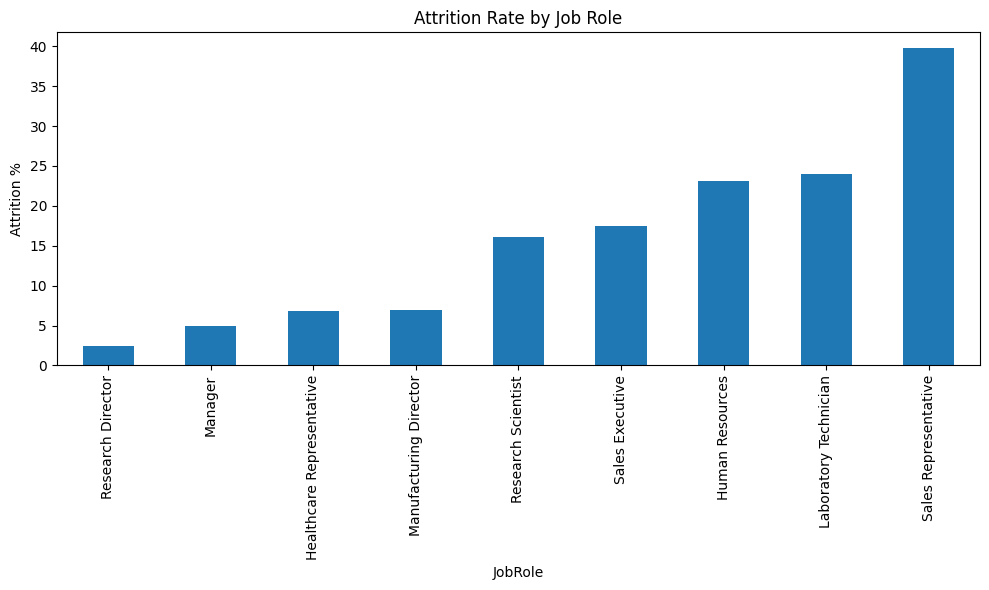

In [17]:
plt.figure(figsize=(10,6))

jobrole_attrition[1].sort_values().plot(
    kind='bar'
)

plt.title("Attrition Rate by Job Role")
plt.ylabel("Attrition %")
plt.tight_layout()

plt.savefig("chart1_jobrole.png")

plt.show()

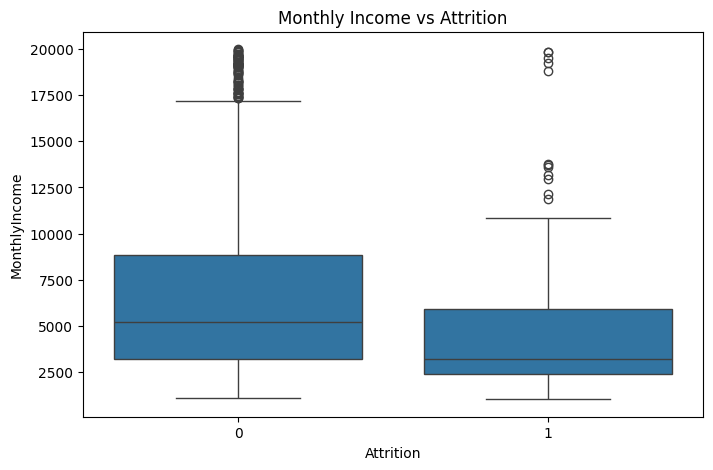

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)

plt.title("Monthly Income vs Attrition")

plt.savefig("chart2_income_boxplot.png")

plt.show()

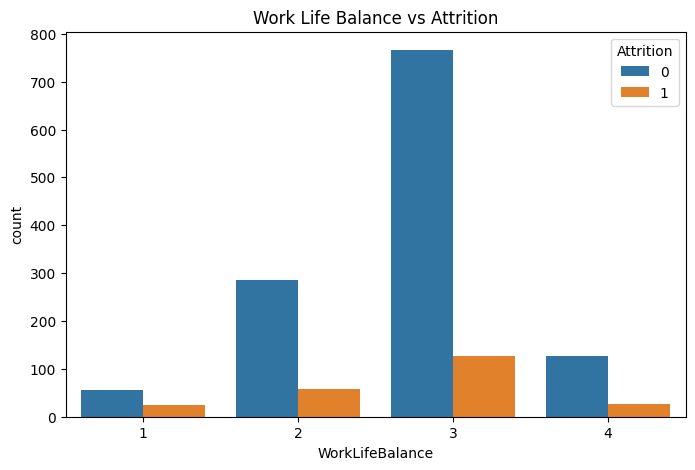

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='WorkLifeBalance',
    hue='Attrition',
    data=df
)

plt.title("Work Life Balance vs Attrition")

plt.savefig("chart_worklife.png")

plt.show()

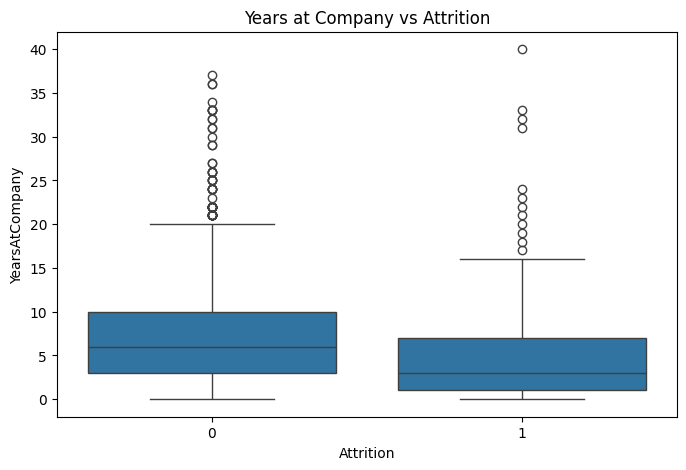

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='YearsAtCompany',
    data=df
)

plt.title("Years at Company vs Attrition")

plt.savefig("chart_years_company.png")

plt.show()

In [21]:
lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42
)

lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [22]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [23]:
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [24]:
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}
results = []

In [25]:
for name, model in models.items():

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    precision = precision_score(y_test,y_pred)

    recall = recall_score(y_test,y_pred)

    f1 = f1_score(y_test,y_pred)

    roc_auc = roc_auc_score(y_test,y_prob)

    results.append([
        name,
        precision,
        recall,
        f1,
        roc_auc
    ])

    print("\n")
    print("="*50)
    print(name)
    print("="*50)

    print(classification_report(
        y_test,
        y_pred
    ))



Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294



Random Forest
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.50      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.67      0.53      0.53       294
weighted avg       0.79      0.84      0.79       294



Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg    

In [26]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

results_df

,Model,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.345238,0.617021,0.442748,0.798260
1,Random Forest,0.500000,0.085106,0.145455,0.768886
2,Gradient Boosting,0.588235,0.212766,0.312500,0.794125


In [27]:
best_model_name = results_df.sort_values(
    by="ROC AUC",
    ascending=False
).iloc[0]["Model"]

print("Best Model:", best_model_name)

model_dict = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

best_model = model_dict[best_model_name]

Best Model: Logistic Regression


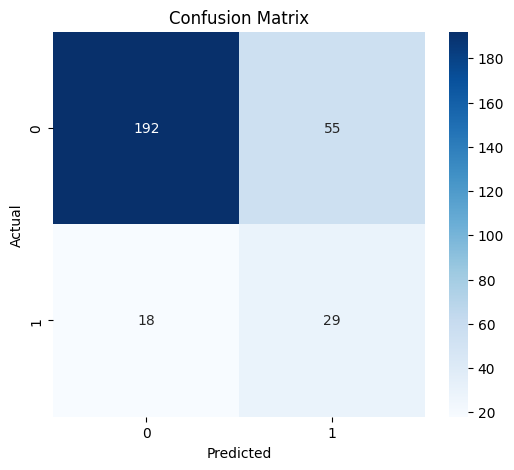

In [28]:


y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("chart3_confusion_matrix.png")

plt.show()

In [29]:
if best_model_name == "Logistic Regression":

    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": abs(best_model.coef_[0])
    })

else:

    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    })

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

top10 = importance.head(10)

print(top10)

                             Feature  Importance
34     JobRole_Laboratory Technician    0.810172
43                      OverTime_Yes    0.771095
23  BusinessTravel_Travel_Frequently    0.722538
16                 TotalWorkingYears    0.660270
7                           JobLevel    0.650173
40      JobRole_Sales Representative    0.531090
24      BusinessTravel_Travel_Rarely    0.512780
27      EducationField_Life Sciences    0.512319
21           YearsSinceLastPromotion    0.499063
26                  Department_Sales    0.470587


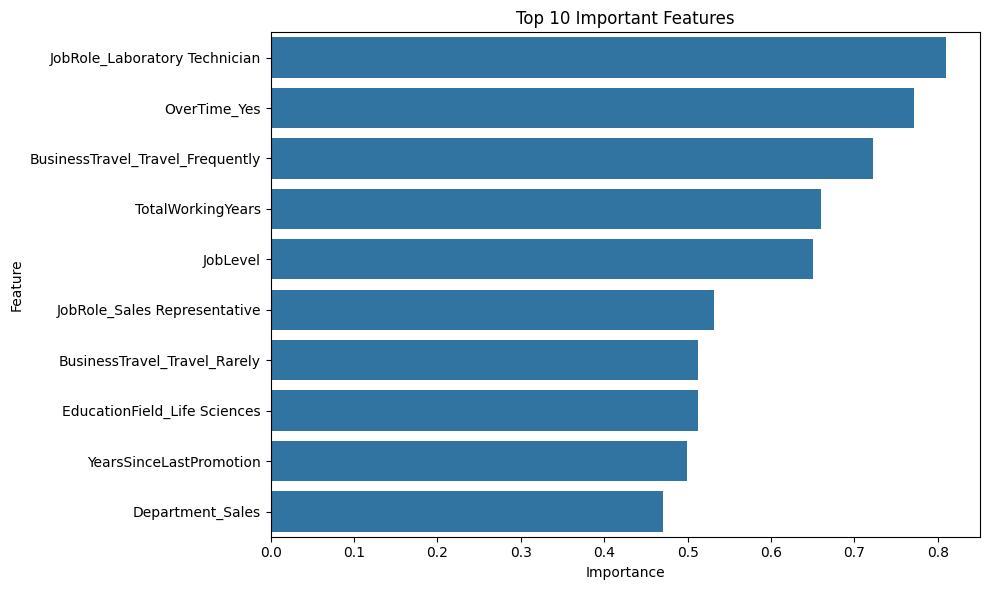

In [30]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title(
    "Top 10 Important Features"
)

plt.tight_layout()

plt.savefig(
    "chart4_feature_importance.png"
)

plt.show()

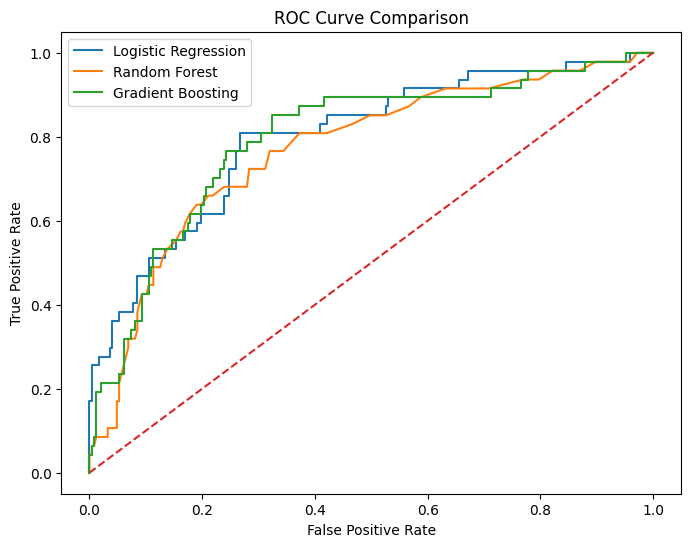

In [31]:
plt.figure(figsize=(8,6))

for name, model in models.items():

    y_prob = model.predict_proba(
        X_test
    )[:,1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=name
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.savefig(
    "chart5_roc_curve.png"
)

plt.show()

In [35]:
print("Logistic Regression was selected as the best model because it achieved the highest ROC-AUC score while also being the most interpretable model for HR decision-making.")

Logistic Regression was selected as the best model because it achieved the highest ROC-AUC score while also being the most interpretable model for HR decision-making.


In [33]:
print("""
HR Insights & Business Recommendations

1. The Sales department experiences the highest employee attrition rate (20.63%), making it the most critical area for retention efforts.

2. Among all job roles, Sales Representatives show the highest attrition rate (39.76%), followed by Laboratory Technicians (23.94%) and Human Resources employees (23.08%).

3. Employees who leave the company generally have lower monthly incomes than employees who stay, indicating that compensation plays a role in attrition.

4. Attrition is more common among employees with fewer years at the company, suggesting that early-career employees are at a higher risk of leaving.

5. Work-life balance, overtime requirements, total working years, and job role were identified as important factors influencing employee attrition.

Recommendations:

• HR should prioritize retention programs for Sales Representatives and Laboratory Technicians, as these groups show the highest risk of leaving.

• Conduct regular career development discussions, mentoring programs, and employee engagement initiatives for employees during their first few years at the company.

• Review overtime policies and workload distribution to improve employee satisfaction and work-life balance.

Limitation:

This model is based on historical employee data and may not capture personal factors such as family situations, health concerns, workplace relationships, or external job opportunities. Therefore, predictions should be used as a decision-support tool rather than the sole basis for HR decisions.
""")



HR Insights & Business Recommendations

1. The Sales department experiences the highest employee attrition rate (20.63%), making it the most critical area for retention efforts.

2. Among all job roles, Sales Representatives show the highest attrition rate (39.76%), followed by Laboratory Technicians (23.94%) and Human Resources employees (23.08%).

3. Employees who leave the company generally have lower monthly incomes than employees who stay, indicating that compensation plays a role in attrition.

4. Attrition is more common among employees with fewer years at the company, suggesting that early-career employees are at a higher risk of leaving.

5. Work-life balance, overtime requirements, total working years, and job role were identified as important factors influencing employee attrition.

Recommendations:

• HR should prioritize retention programs for Sales Representatives and Laboratory Technicians, as these groups show the highest risk of leaving.

• Conduct regular career deve